# 📈 Training Performance & Convergence Analysis

In [4]:
%matplotlib inline

import os
import json
import numpy as np
import matplotlib.pyplot as plt

### Training History Log

In [5]:
history_path = '../training_history.json'

if os.path.exists(history_path):
    with open(history_path, 'r') as file:
        history = json.load(file)
        
    epoch_losses = history['train_loss']
    best_epoch = history['best_epoch']
    min_loss_val = epoch_losses[best_epoch - 1]
    epochs = np.arange(1, len(epoch_losses) + 1)
    
    print(f"[INFO] Successfully loaded training metrics.")
    print(f"Total Epochs Processed: {len(epoch_losses)}")
    print(f"Lowest Achieved Loss:   {min_loss_val:.4f} (at Epoch {best_epoch})")
else:
    print(f"[ERROR] '{history_path}' not found!")
    print("Please run 'python main.py --mode train' first to generate the metrics file.")
    
    # Fallback empty lists to prevent graphing errors
    epoch_losses = []
    epochs = []
    best_epoch = 0
    min_loss_val = 0

[INFO] Successfully loaded training metrics.
Total Epochs Processed: 25
Lowest Achieved Loss:   0.3009 (at Epoch 22)


### Loss Optimization Curve

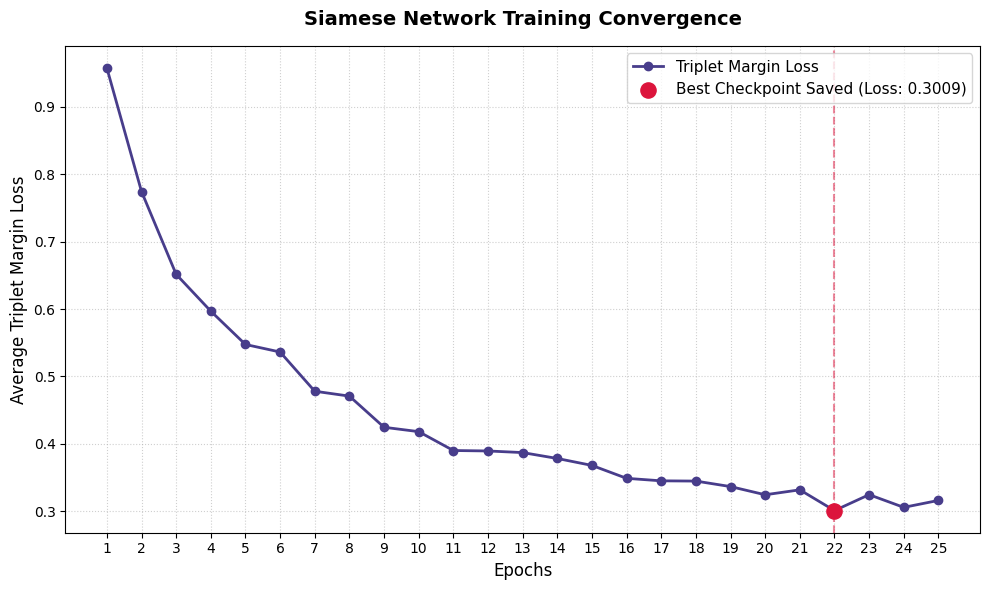

In [6]:
if len(epoch_losses) > 0:
    plt.figure(figsize=(10, 6))

    # Plot the continuous loss values
    plt.plot(epochs, epoch_losses, color='darkslateblue', marker='o', lw=2, label='Triplet Margin Loss')

    # Highlight the exact best model checkpoint saved by Early Stopping
    plt.scatter(best_epoch, min_loss_val, color='crimson', s=120, zorder=5, 
                label=f'Best Checkpoint Saved (Loss: {min_loss_val:.4f})')

    # Draw a vertical indicator line for the rollback target
    plt.axvline(x=best_epoch, color='crimson', linestyle='--', alpha=0.5)

    plt.title('Siamese Network Training Convergence', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Average Triplet Margin Loss', fontsize=12)
    plt.xticks(epochs)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11, loc='upper right')

    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot.")